In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set consistent style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configure for publication-quality output
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load your data
df = pd.read_csv('data/processed/master_dataset.csv')
print(f"Loaded {len(df)} rows")

Loaded 276 rows


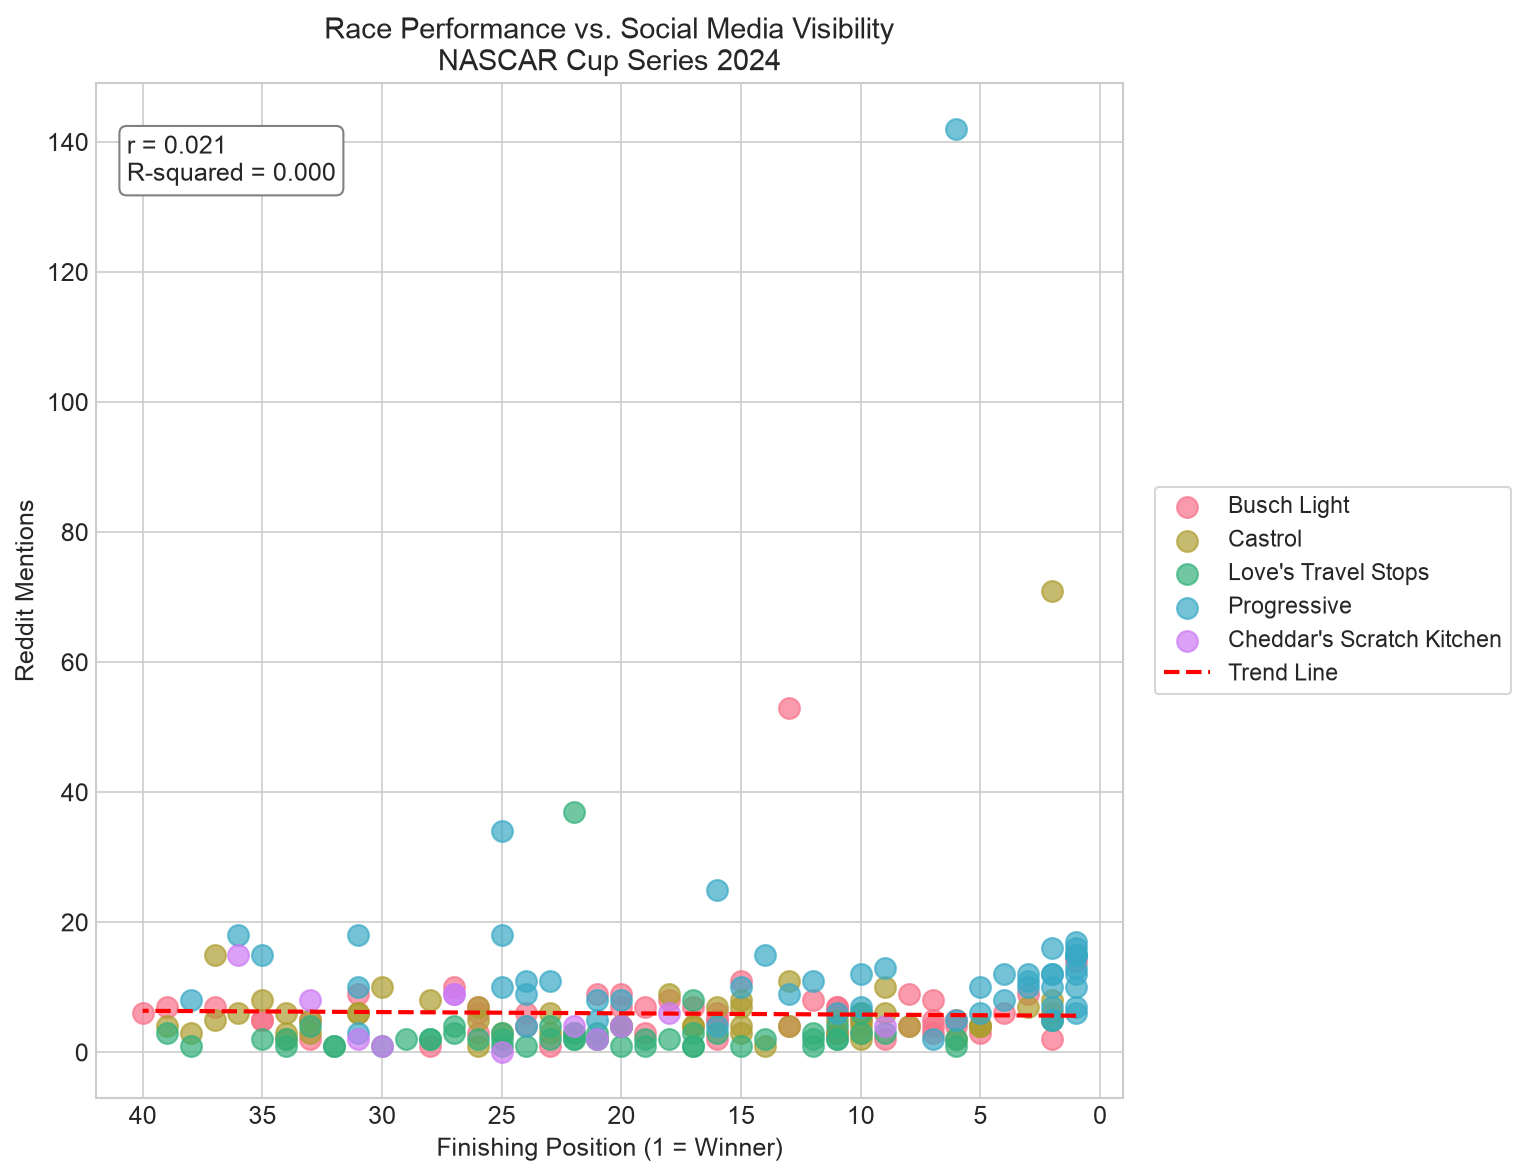

Chart saved: scatter_finish_vs_reddit.png


In [34]:
# Create figure
fig, ax = plt.subplots(figsize=(13, 8))

# Get unique sponsors for color coding
sponsors = [s for s in df['primary_sponsor'].unique() if s != 'Other/Unknown']
colors = sns.color_palette("husl", len(sponsors))

# Plot each sponsor with different color
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax.scatter(
        sponsor_data['finish_position'],
        sponsor_data['reddit_mention_count'],
        label=sponsor,
        alpha=0.7,
        s=100,
        c=[colors[i]]
    )

# Add trend line for overall data
z = np.polyfit(df['finish_position'], df['reddit_mention_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['finish_position'].min(), df['finish_position'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')

# Calculate and display R-squared
correlation = df['finish_position'].corr(df['reddit_mention_count'])
r_squared = correlation ** 2

# Stat box in the top-left corner — the emptiest region of this particular
# scatter (the high-Reddit outliers all sit toward the right/top-right), so
# it won't sit on top of data the way the old top-right placement did.
ax.annotate(
    f'r = {correlation:.3f}\nR-squared = {r_squared:.3f}',
    xy=(0.03, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray')
)

# Customize chart
ax.set_xlabel('Finishing Position (1 = Winner)', fontsize=12)
ax.set_ylabel('Reddit Mentions', fontsize=12)
ax.set_title('Race Performance vs. Social Media Visibility\nNASCAR Cup Series 2024', fontsize=14)
ax.invert_xaxis()  # Lower position numbers on left (better finishes)

# Legend fully outside the plot area (not just nudged past the edge) so it
# never overlaps a data point, regardless of where points happen to fall.
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=11)

fig.tight_layout(rect=[0, 0, 0.8, 1])
plt.savefig('data/plots/scatter_finish_vs_reddit.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: scatter_finish_vs_reddit.png")

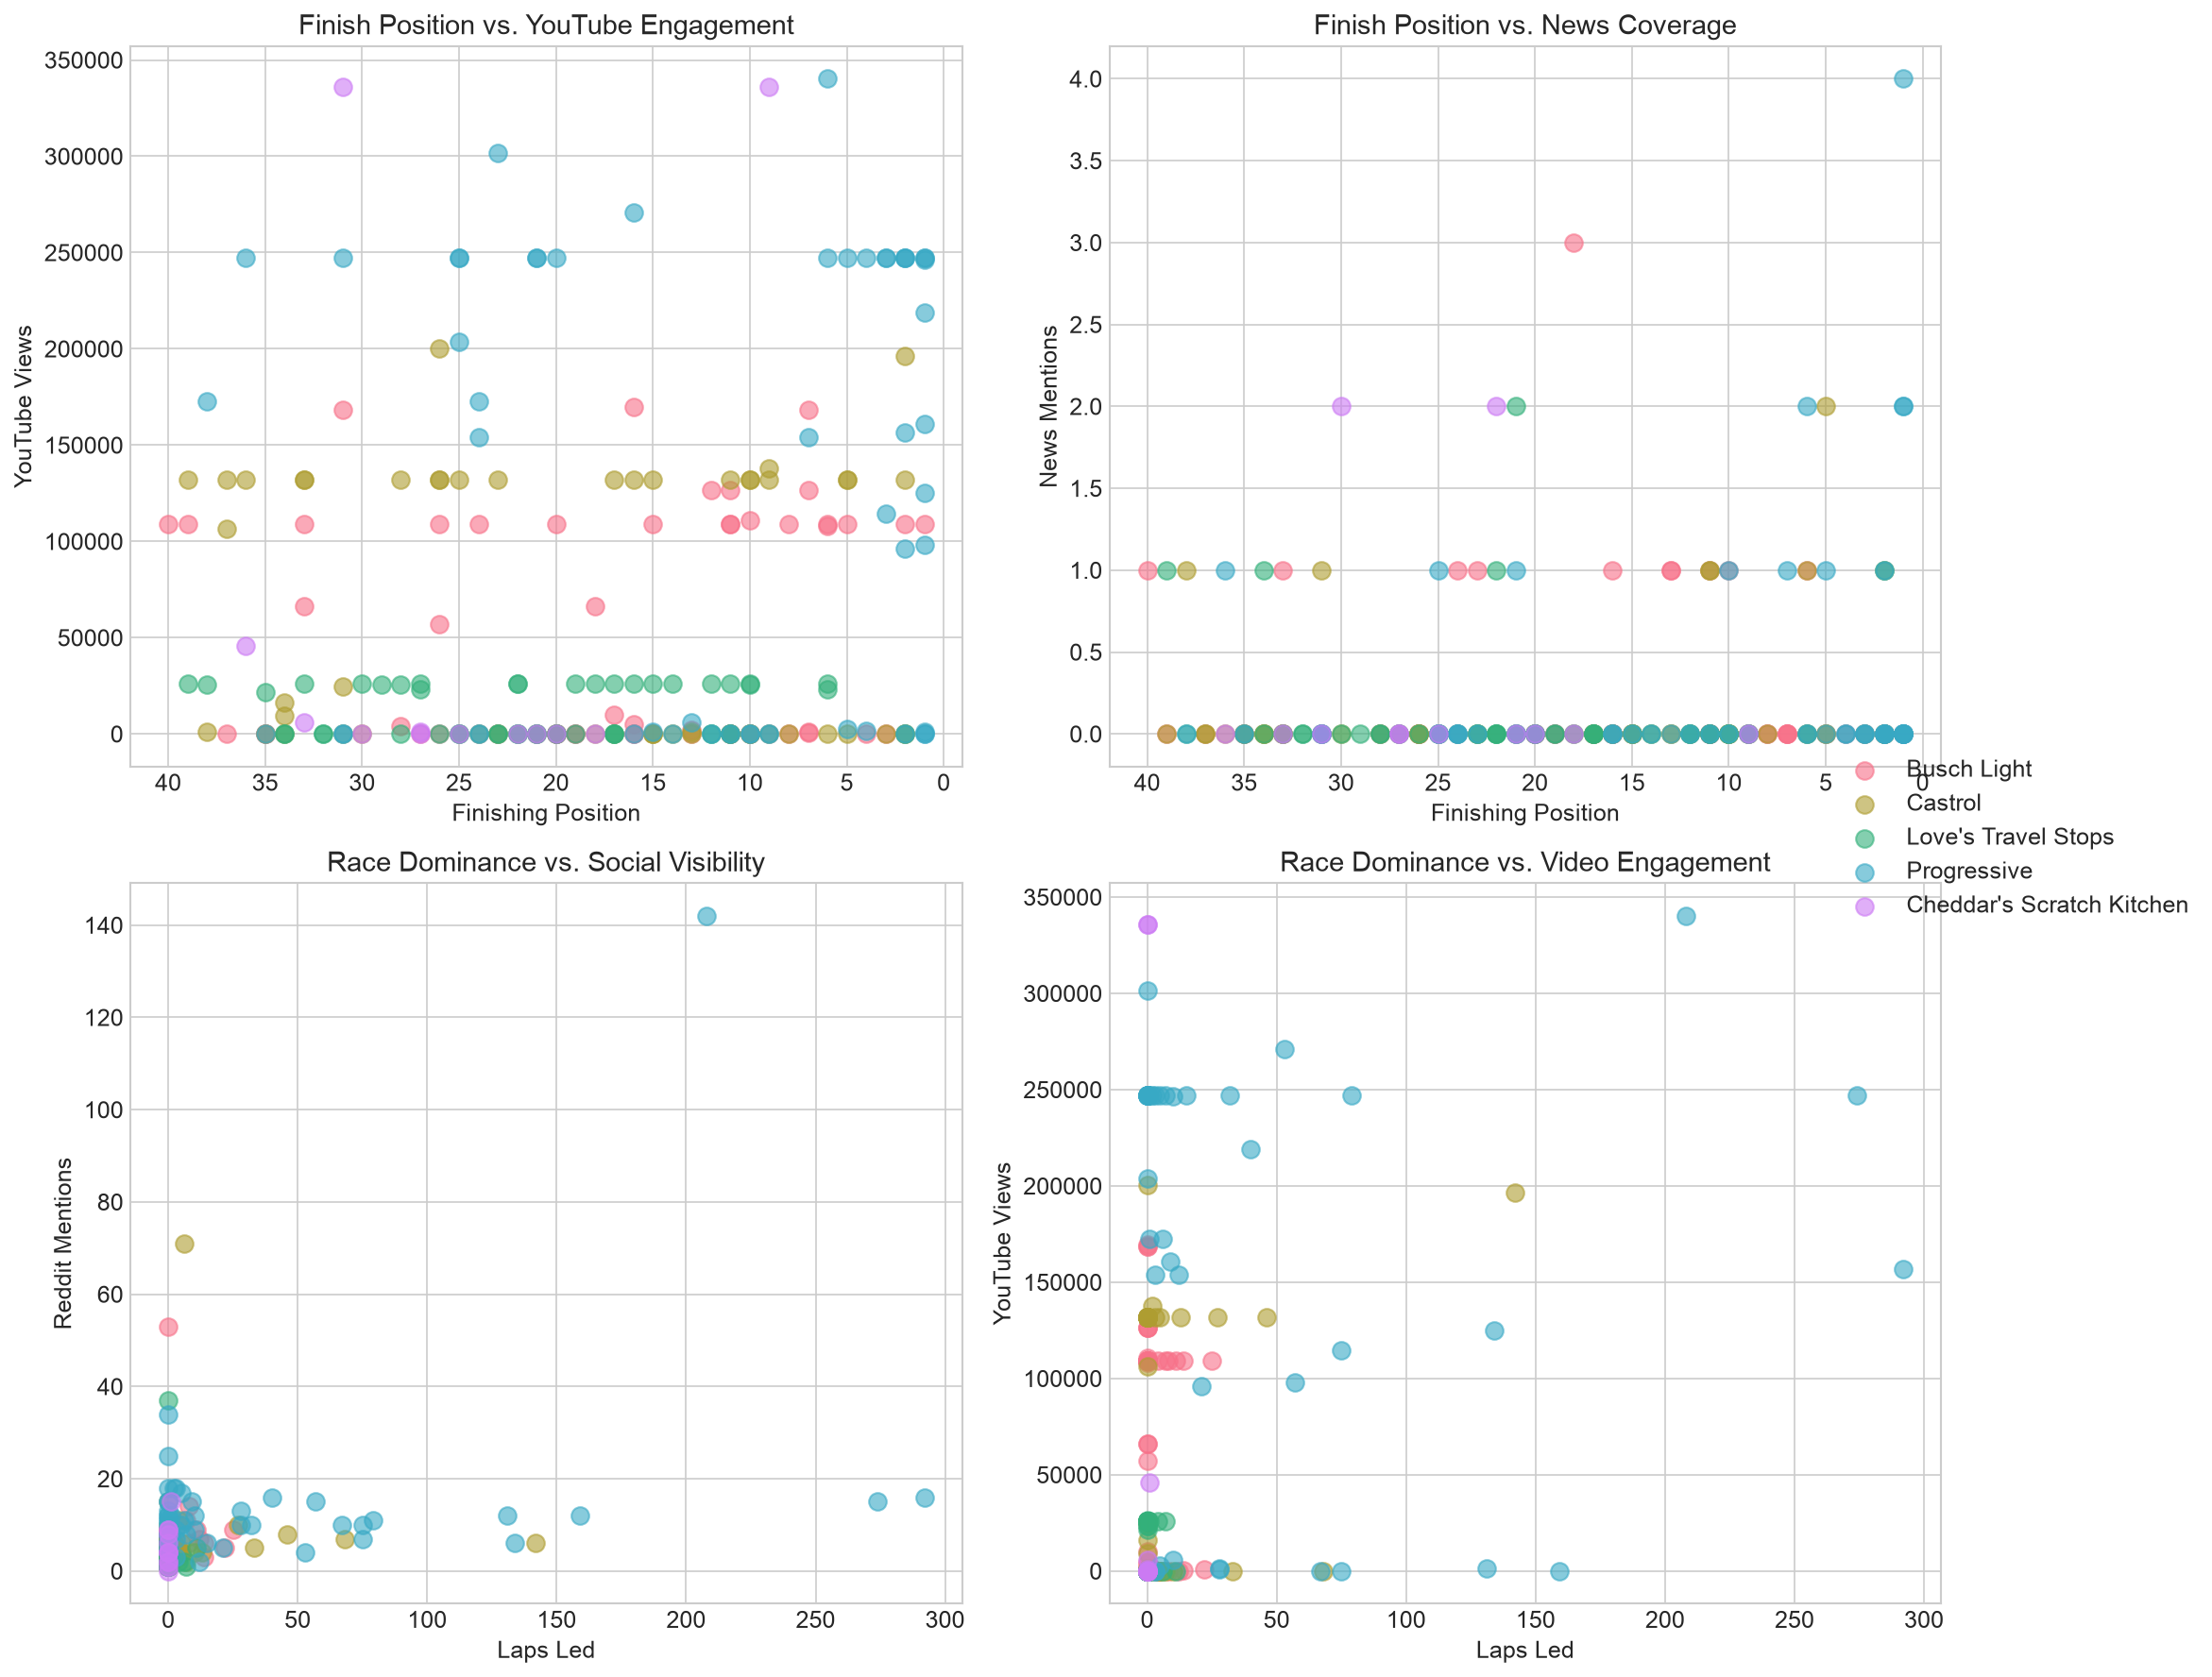

Chart saved: scatter_grid_all_metrics.png


In [35]:
# Create a 2x2 grid of scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Finish Position vs YouTube Views
ax1 = axes[0, 0]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax1.scatter(sponsor_data['finish_position'], sponsor_data['youtube_total_view_count'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax1.set_xlabel('Finishing Position')
ax1.set_ylabel('YouTube Views')
ax1.set_title('Finish Position vs. YouTube Engagement')
ax1.invert_xaxis()

# Plot 2: Finish Position vs News Mentions
ax2 = axes[0, 1]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax2.scatter(sponsor_data['finish_position'], sponsor_data['news_total_mentions'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax2.set_xlabel('Finishing Position')
ax2.set_ylabel('News Mentions')
ax2.set_title('Finish Position vs. News Coverage')
ax2.invert_xaxis()

# Plot 3: Laps Led vs Reddit Mentions
ax3 = axes[1, 0]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax3.scatter(sponsor_data['laps_led'], sponsor_data['reddit_mention_count'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax3.set_xlabel('Laps Led')
ax3.set_ylabel('Reddit Mentions')
ax3.set_title('Race Dominance vs. Social Visibility')

# Plot 4: Laps Led vs YouTube Views
ax4 = axes[1, 1]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax4.scatter(sponsor_data['laps_led'], sponsor_data['youtube_total_view_count'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax4.set_xlabel('Laps Led')
ax4.set_ylabel('YouTube Views')
ax4.set_title('Race Dominance vs. Video Engagement')

# Add shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5))

plt.tight_layout()
plt.savefig('data/plots/scatter_grid_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: scatter_grid_all_metrics.png")

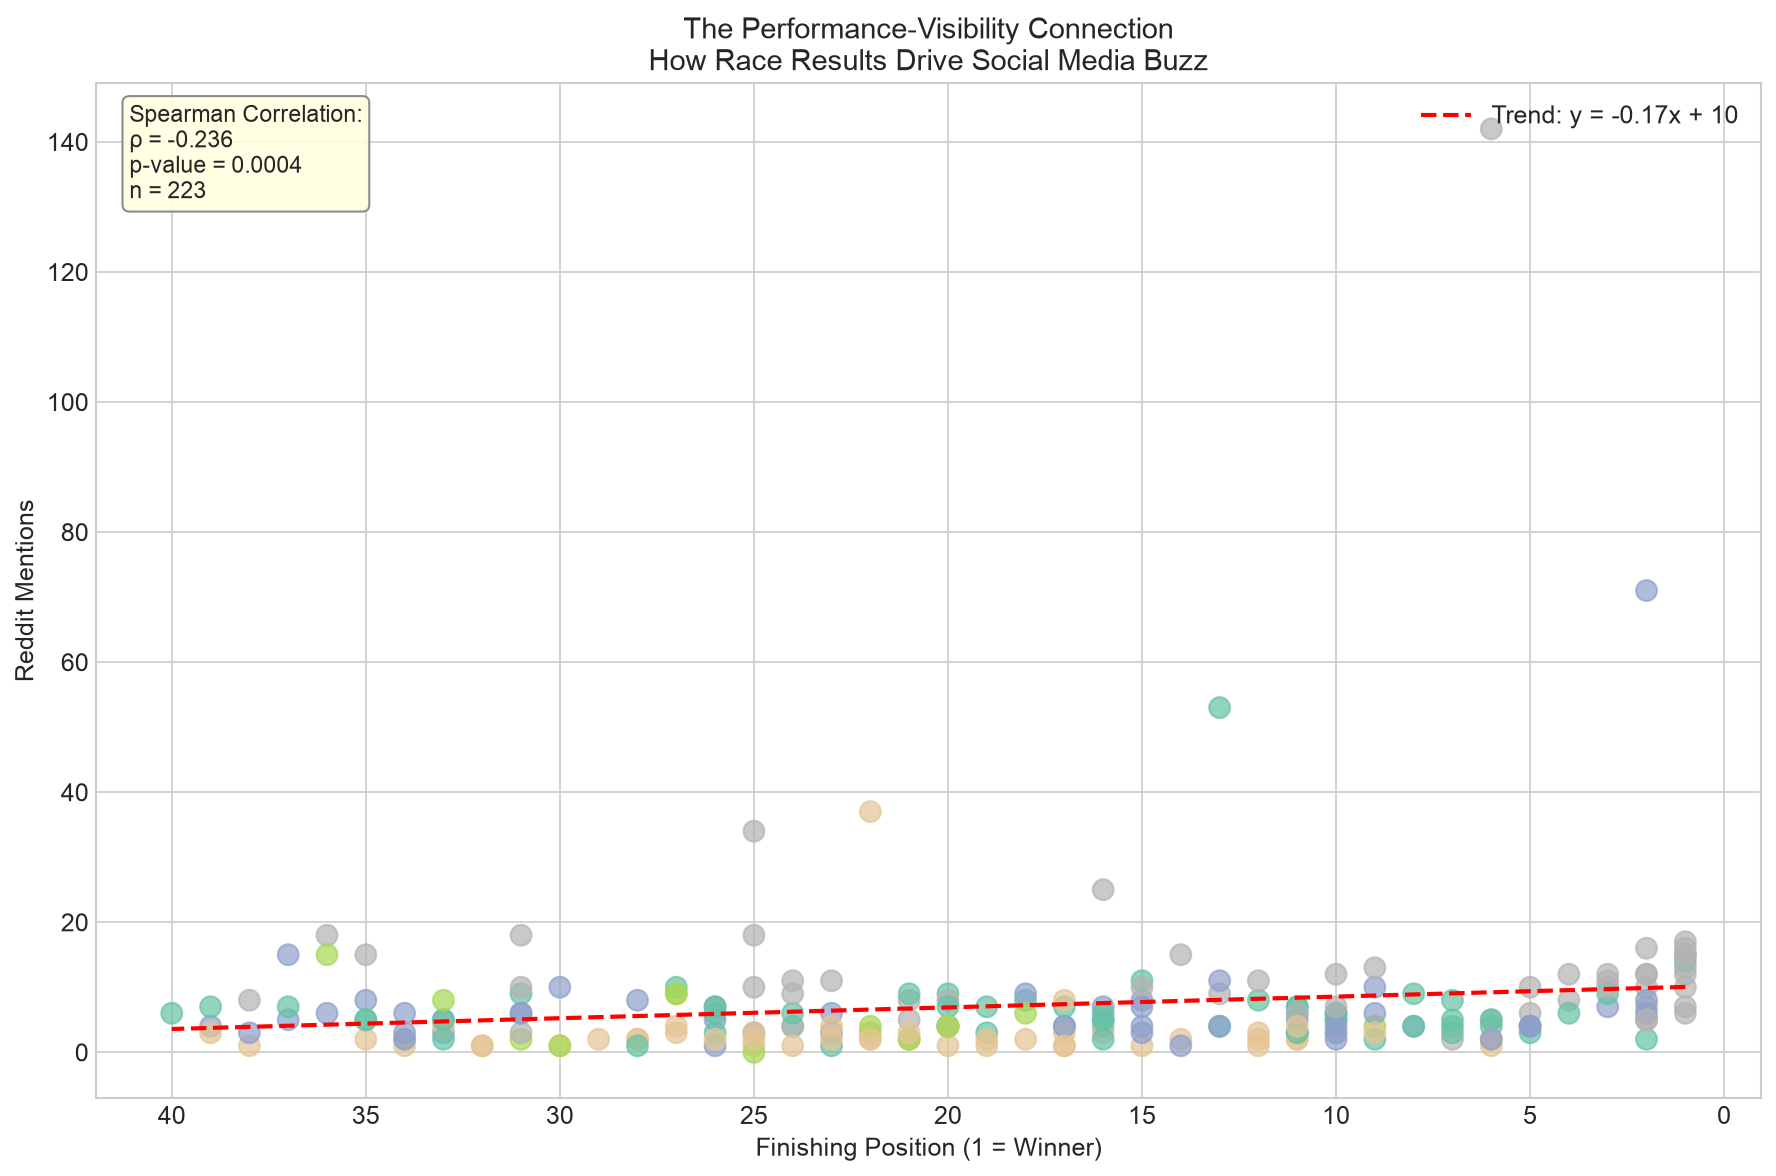

In [36]:
# Enhanced scatter plot with regression statistics
# Filter out "Other/Unknown" the same way statistical_analysis.ipynb does —
# those rows are aggregated placeholders (reddit_mention_count = 0 for all of
# them) and otherwise dilute the correlation.
plot_df = df[df['primary_sponsor'] != 'Other/Unknown']

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot with all data
scatter = ax.scatter(
    plot_df['finish_position'],
    plot_df['reddit_mention_count'],
    c=plot_df['primary_sponsor'].astype('category').cat.codes,
    cmap='Set2',
    alpha=0.7,
    s=100
)

# Spearman, not Pearson — reddit_mention_count is skewed with real outliers
# (confirmed via histogram + Shapiro-Wilk in statistical_analysis.ipynb), so
# rank correlation is the appropriate test here, same as that notebook uses.
rho, p_value = stats.spearmanr(plot_df['finish_position'], plot_df['reddit_mention_count'])

# linregress is still fine purely for drawing a visual trend line (least-squares
# fit through the points) — it's just no longer the basis for the reported stats.
slope, intercept, _, _, _ = stats.linregress(plot_df['finish_position'], plot_df['reddit_mention_count'])

# Plot regression line
x_line = np.linspace(plot_df['finish_position'].min(), plot_df['finish_position'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Trend: y = {slope:.2f}x + {intercept:.0f}')

# Add annotation box with statistics
stats_text = f'Spearman Correlation:\n'
stats_text += f'ρ = {rho:.3f}\n'
stats_text += f'p-value = {p_value:.4f}\n'
stats_text += f'n = {len(plot_df)}'

ax.annotate(
    stats_text,
    xy=(0.02, 0.98),
    xycoords='axes fraction',
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.9)
)

ax.set_xlabel('Finishing Position (1 = Winner)', fontsize=12)
ax.set_ylabel('Reddit Mentions', fontsize=12)
ax.set_title('The Performance-Visibility Connection\nHow Race Results Drive Social Media Buzz', fontsize=14)
ax.invert_xaxis()
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('data/plots/scatter_with_regression.png', dpi=150)
plt.show()

[0.45329603 0.32656065 0.22014332]
[0.69674768 0.48208574 0.53116476]


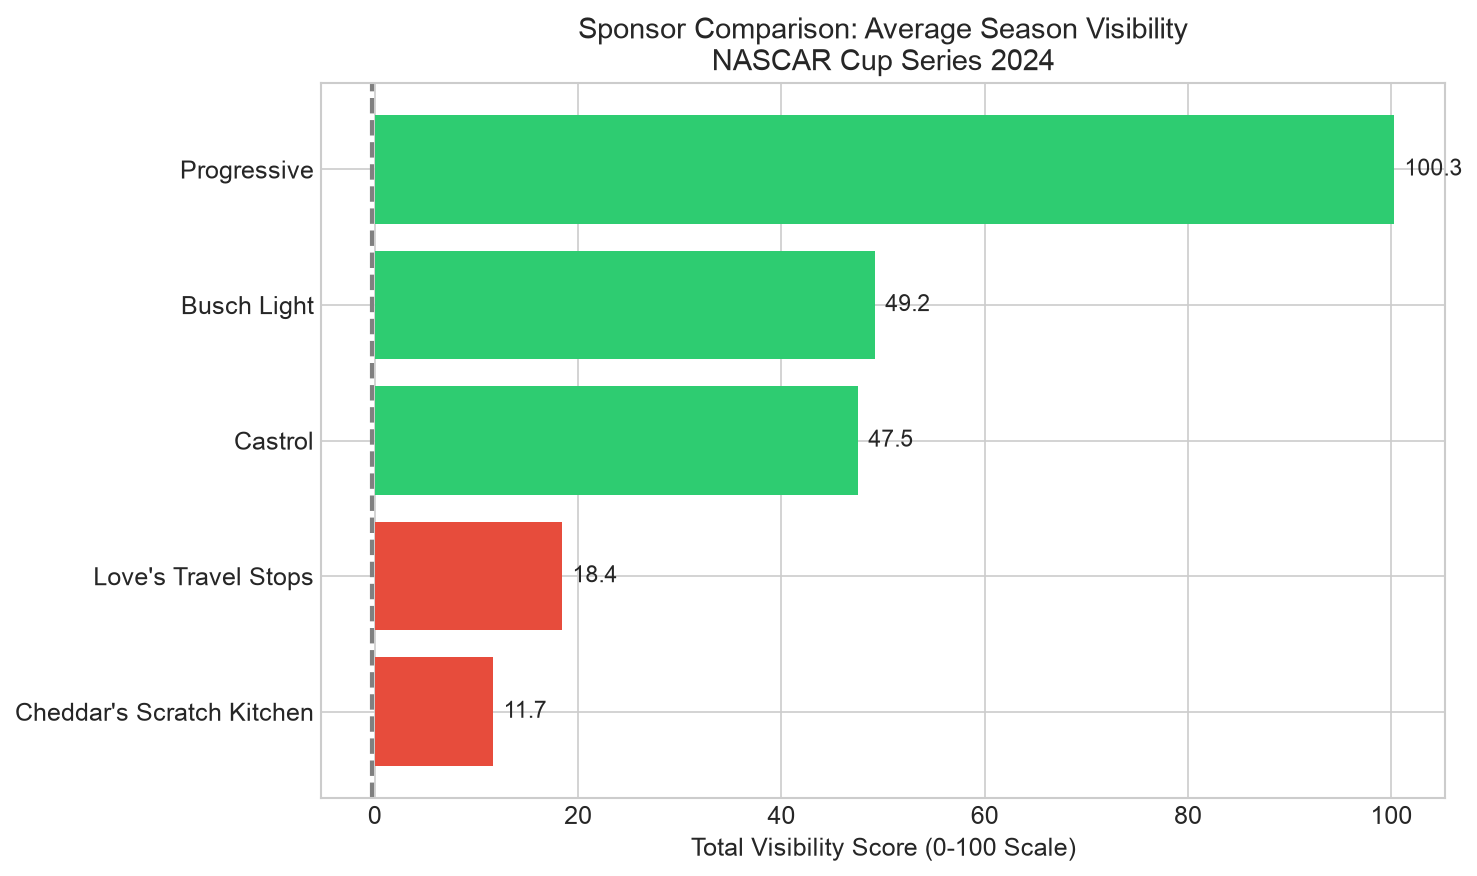

Chart saved: bar_sponsor_visibility.png


In [37]:
# Calculate average visibility metrics by sponsor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sponsor_summary = df[df['primary_sponsor'] != 'Other/Unknown']

# Create composite visibility score for comparison
# (Normalize each metric to 0-100 scale, then average)
sponsor_summary['Reddit_Normalized'] = (
    (sponsor_summary['reddit_mention_count'] - sponsor_summary['reddit_mention_count'].mean()) /
    (sponsor_summary['reddit_mention_count'].std())
)
sponsor_summary['YouTube_Normalized'] = (
    (sponsor_summary['youtube_total_view_count'] - sponsor_summary['youtube_total_view_count'].mean()) /
    (sponsor_summary['youtube_total_view_count'].std())
)
sponsor_summary['News_Normalized'] = (
    (sponsor_summary['news_total_mentions'] - sponsor_summary['news_total_mentions'].mean()) /
    (sponsor_summary['news_total_mentions'].std())
)

X = sponsor_summary[['Reddit_Normalized', 'News_Normalized', 'YouTube_Normalized']]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)
print(pca.explained_variance_ratio_)   # how much each PC explains
print(pca.components_[0])              # loadings for PC1 — your data-driven weights


sponsor_summary['Visibility_Score'] = (
    sponsor_summary['Reddit_Normalized'] * abs(pca.components_[0][0])+
    sponsor_summary['YouTube_Normalized'] * abs(pca.components_[0][2]) +
    sponsor_summary['News_Normalized'] * abs(pca.components_[0][1])
).round(2)

shift = -sponsor_summary['Visibility_Score'].min()
sponsor_summary['Visibility_Score_Shifted'] = sponsor_summary['Visibility_Score'] + shift



sponsor_summary_aggregated = sponsor_summary.groupby('primary_sponsor').agg(
    Total_Visibility=('Visibility_Score_Shifted', 'sum')
)

# Sort by visibility score
sponsor_summary_aggregated = sponsor_summary_aggregated.sort_values('Total_Visibility', ascending=True)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if v >= sponsor_summary_aggregated['Total_Visibility'].median()
          else '#e74c3c' for v in sponsor_summary_aggregated['Total_Visibility']]

bars = ax.barh(sponsor_summary_aggregated.index, sponsor_summary_aggregated['Total_Visibility'], color=colors)

# Add value labels
for bar, value in zip(bars, sponsor_summary_aggregated['Total_Visibility']):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}', va='center', fontsize=11)

ax.set_xlabel('Total Visibility Score (0-100 Scale)', fontsize=12)
ax.set_title('Sponsor Comparison: Average Season Visibility\nNASCAR Cup Series 2024', fontsize=14)
ax.axvline(x=sponsor_summary['Visibility_Score'].median(), color='gray',
           linestyle='--', linewidth=2, label='Median')

plt.tight_layout()
plt.savefig('data/plots/bar_sponsor_visibility.png', dpi=150)
plt.show()

print("Chart saved: bar_sponsor_visibility.png")

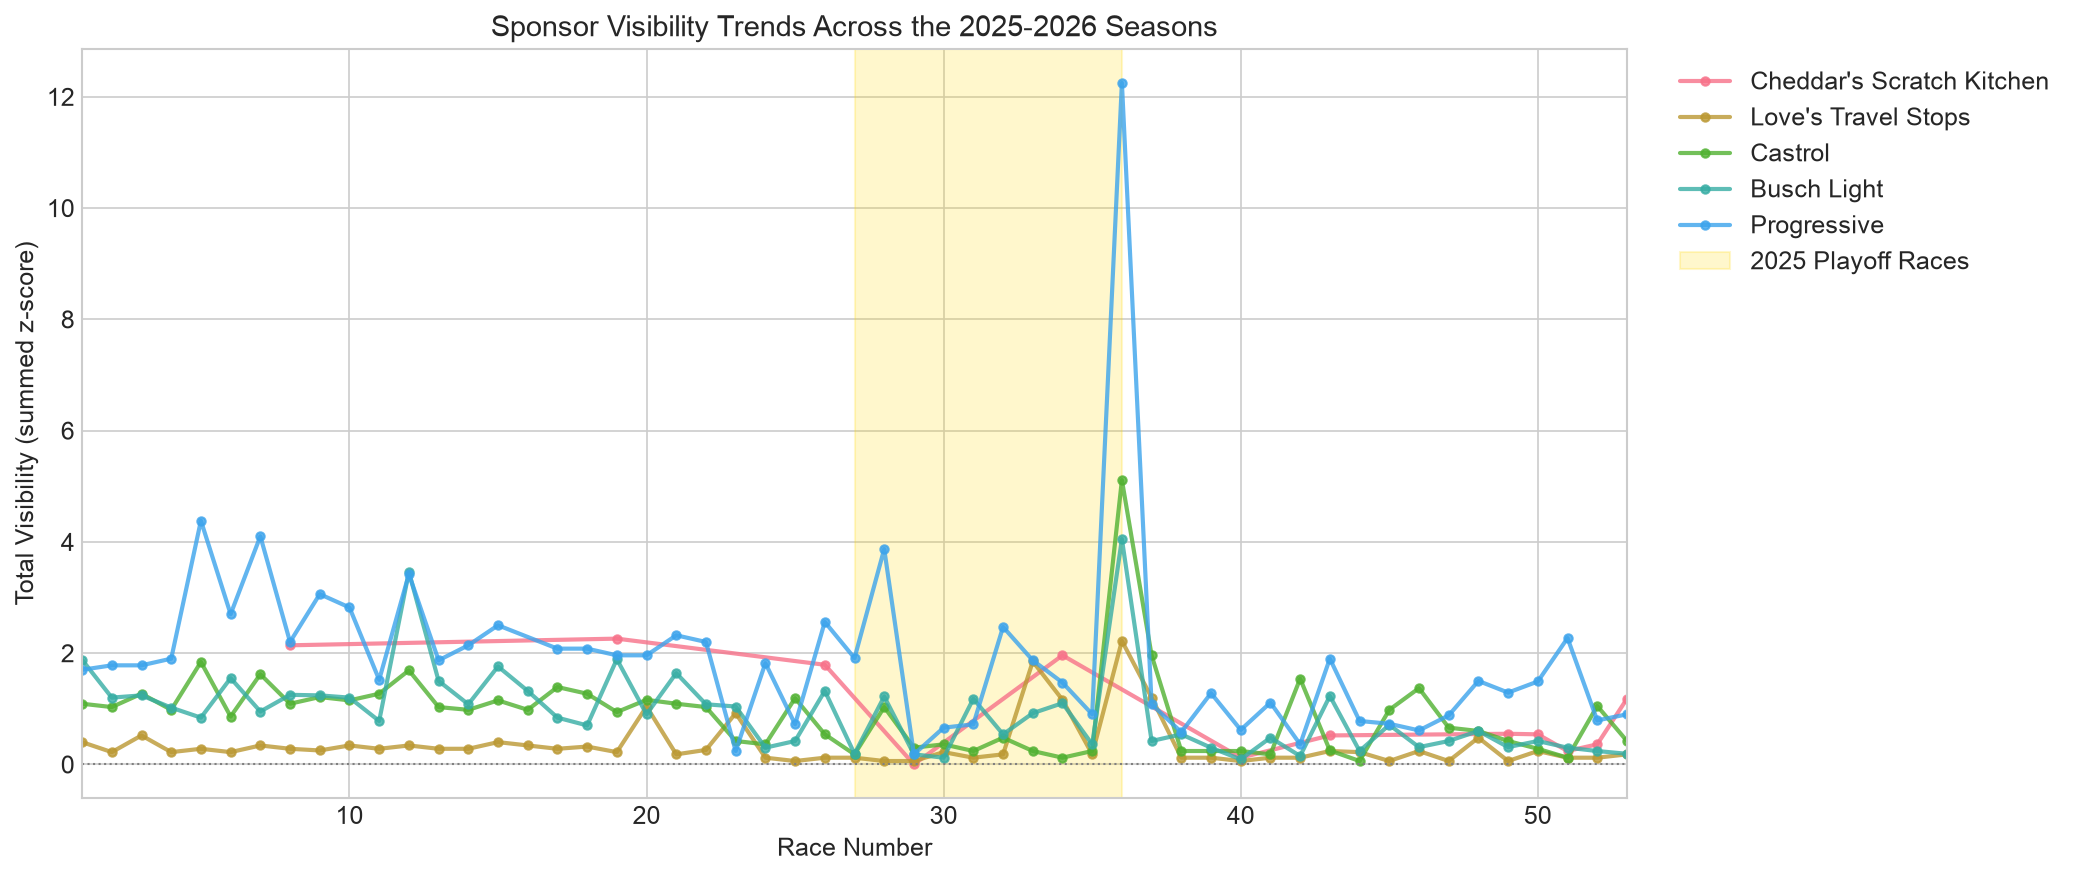

Chart saved: line_visibility_trends.png


In [43]:
# Create race number if not present
if 'race_number' not in df.columns:
    df['Race_Number'] = df.groupby('primary_sponsor').cumcount() + 1

# Combine the three visibility metrics via z-score rather than an arbitrary
# divisor (e.g. "/1000" for YouTube) — each metric gets centered on its own
# mean and scaled by its own spread, so no channel dominates the sum just
# because its raw units happen to be larger.
#
# The mean/std baseline is computed over the 5 tracked sponsors only:
# "Other/Unknown" rows are aggregated placeholders (near-zero on every
# metric) and would drag the baseline if included.
#viz_cols = ['reddit_mention_count', 'news_total_mentions', 'youtube_total_view_count']
##baseline = df[df['primary_sponsor'] != 'Other/Unknown']

#for col in viz_cols:
    #mean, std = baseline[col].mean(), baseline[col].std()
    #df[f'{col}_z'] = (df[col] - mean) / std

#df['Total_Visibility'] = df[[f'{col}_z' for col in viz_cols]].sum(axis=1)

df['Total_Visibility'] = sponsor_summary['Visibility_Score_Shifted']

# Create line chart
fig, ax = plt.subplots(figsize=(14, 6))

for sponsor in sponsors:
    sponsor_data = df[df['primary_sponsor'] == sponsor].sort_values('race_number')
    ax.plot(sponsor_data['race_number'], sponsor_data['Total_Visibility'],
            marker='o', markersize=4, linewidth=2, alpha=0.8, label=sponsor)

# race_number runs continuously across seasons (1-36 = 2025, 37+ = 2026), so
# the playoffs land at a different absolute race_number each season: 27-36
# for 2025. The 2026 season's playoff window (race_number 63-72) hasn't
# happened yet in this data (it currently stops at 53), so only 2025's
# playoff span is shaded.
ax.axvspan(27, 36, alpha=0.2, color='gold', label='2025 Playoff Races')
ax.axhline(0, color='gray', linewidth=1, linestyle=':')

ax.set_xlabel('Race Number', fontsize=12)
ax.set_ylabel('Total Visibility (summed z-score)', fontsize=12)
ax.set_title('Sponsor Visibility Trends Across the 2025-2026 Seasons', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlim(df['race_number'].min(), df['race_number'].max())

plt.tight_layout()
plt.savefig('data/plots/line_visibility_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: line_visibility_trends.png")

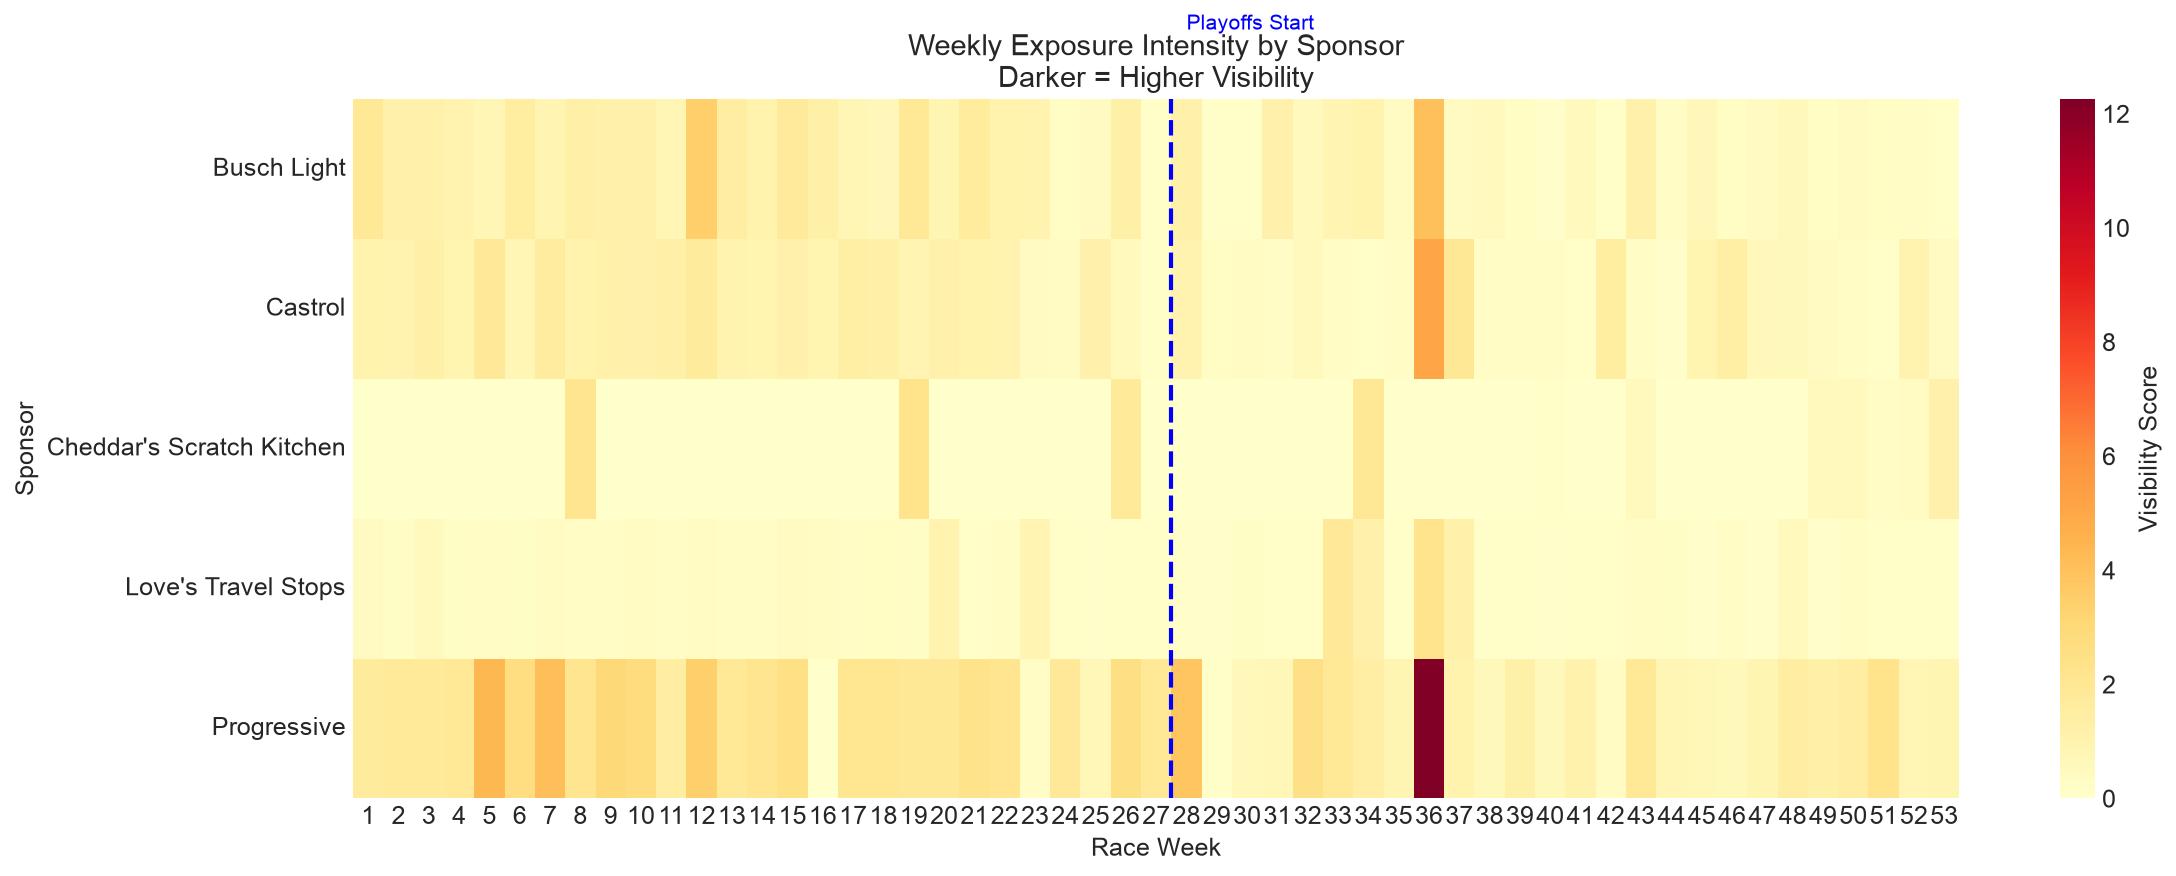

Chart saved: heatmap_weekly_exposure.png


In [44]:
# Create week number from race date (or use race number as proxy)
df['Week'] = df['race_number']  # Simplified - each race = 1 week

# Pivot for heatmap
heatmap_data = df.pivot_table(
    values='Total_Visibility',
    index='primary_sponsor',
    columns='Week',
    aggfunc='mean'
).fillna(0)

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Visibility Score'},
    ax=ax
)

# Add playoff marker
ax.axvline(x=27, color='blue', linewidth=2, linestyle='--')
ax.text(27.5, -0.5, 'Playoffs Start', fontsize=10, color='blue')

ax.set_xlabel('Race Week', fontsize=12)
ax.set_ylabel('Sponsor', fontsize=12)
ax.set_title('Weekly Exposure Intensity by Sponsor\nDarker = Higher Visibility', fontsize=14)

plt.tight_layout()
plt.savefig('data/plots/heatmap_weekly_exposure.png', dpi=150)
plt.show()

print("Chart saved: heatmap_weekly_exposure.png")

In [ ]:
# Calculate channel breakdown by sponsor
channel_breakdown = df[df['primary_sponsor'] != 'Other/Unknown'].groupby('primary_sponsor').agg({
    'reddit_mention_count': 'sum',
    'youtube_total_view_count': 'sum',
    'news_total_mentions': 'sum'
})

yt = channel_breakdown['youtube_total_view_count']
channel_breakdown['YouTube_Scaled'] = (yt - yt.max()) / (yt.min() - yt.max())
reddit = channel_breakdown['reddit_mention_count']
channel_breakdown['Reddit_Scaled'] = (reddit-reddit.max())/(reddit.min()-reddit.max())
news = channel_breakdown['news_total_mentions']
channel_breakdown['News_Scaled'] = (news-news.max())/(news.min()-news.max())
w_reddit, w_news, w_youtube = abs(pca.components_[0][0]), abs(pca.components_[0][1]), abs(pca.components_[0][2])

channel_breakdown['Reddit_Weighted'] = channel_breakdown['Reddit_Scaled'] * w_reddit
channel_breakdown['YouTube_Weighted'] = channel_breakdown['YouTube_Scaled'] * w_youtube
channel_breakdown['News_Weighted'] = channel_breakdown['News_Scaled'] * w_news

total = channel_breakdown['Reddit_Weighted'] + channel_breakdown['YouTube_Weighted'] + channel_breakdown['News_Weighted']
channel_breakdown['Reddit_Pct'] = channel_breakdown['Reddit_Weighted'] / total * 100
channel_breakdown['YouTube_Pct'] = channel_breakdown['YouTube_Weighted'] / total * 100
channel_breakdown['News_Pct'] = channel_breakdown['News_Weighted'] / total * 100

# Sort by total
channel_breakdown = channel_breakdown.sort_values('reddit_mention_count', ascending=True)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

sponsors = channel_breakdown.index

ax.barh(sponsors, channel_breakdown['Reddit_Pct'], label='Reddit', color='#FF4500')
ax.barh(sponsors, channel_breakdown['YouTube_Pct'],
        left=channel_breakdown['Reddit_Pct'], label='YouTube', color='#FF0000')
ax.barh(sponsors, channel_breakdown['News_Pct'],
        left=channel_breakdown['Reddit_Pct'] + channel_breakdown['YouTube_Pct'],
        label='News', color='#4169E1')

ax.set_xlabel('Percentage of Total Visibility', fontsize=12)
ax.set_title('Channel Mix: Where Does Each Sponsor Get Their Visibility?', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('data/plots/stacked_channel_breakdown.png', dpi=150)
plt.show()

print("Chart saved: stacked_channel_breakdown.png")

KeyError: 'News_Scaled'

In [41]:
# Create a findings summary template
findings_template = """
# Visualization Review Summary

## Scatter Plots

### Finish Position vs. Reddit Mentions
- **Observed pattern:** visible correlation, with many outliers that got 
tons of mentions for high placing races, likely pulling the regression line a bit
- **Strength of relationship:** Weak
- **Notable outliers:** some wins/high places get a huge amount of traffic
- **Potential hypothesis:** there is a genuine relationship here

### Finish Position vs. YouTube Views
- **Observed pattern:** slightly less statistically significant same pettern
- **Strength of relationship:** Weak
- **Notable outliers:** no
- **Potential hypothesis:** there is a genuine relationship here

### Laps Led vs. Social Mentions
- **Observed pattern:** real correlation, almost as strong as finish position
- **Does dominance matter?** probably a little, but the real reason
laps led and finish position were similarly correlated for social mentions
is probably due to the fact they are extremely correlated with eachother

## Comparison Charts

### Sponsor Rankings
- **Top visibility sponsors:** Progressive, Busch Light, Castrol
- **Bottom visibility sponsors:** Castrol, Love's Travel Stops, Cheddar's Scratch Kitchen
- **Performance correlation:** higher performance reliably resulted in higher visibility

### Season Trends
- **Peak visibility periods:** of course the playoffs, other than that it varies by sponsor
- **Playoff effect:** stronger
- **Consistency patterns:** all are volitile

### Channel Mix
- **Reddit-heavy sponsors:** Progressive
- **News-heavy sponsors:** none
- **Pattern explanation:** progressive is a new sponsor for a big name so they automatically got talked about
"""

with open('visualization_review.md', 'w') as f:
    f.write(findings_template)

print("Fill out visualization_review.md with your observations")

Fill out visualization_review.md with your observations


In [42]:
# Hypothesis 1: Top 5 finishes generate disproportionately more visibility
top5_mentions = sponsor_summary[sponsor_summary['finish_position'] <= 5]['Visibility_Score'].mean()
outside_top10_mentions = sponsor_summary[sponsor_summary['finish_position'] > 10]['Visibility_Score'].mean()

ratio = top5_mentions / outside_top10_mentions

print("Hypothesis Test: Top 5 Effect")
print(f"  Average visibility for Top 5 finishes: {top5_mentions:.1f}")
print(f"  Average visibility for P11+: {outside_top10_mentions:.1f}")
print(f"  Ratio: {ratio:.2f}x")
print(f"  Hypothesis: Top 5 finishes generate {ratio:.1f}x visibility")

Hypothesis Test: Top 5 Effect
  Average visibility for Top 5 finishes: 0.7
  Average visibility for P11+: -0.2
  Ratio: -3.33x
  Hypothesis: Top 5 finishes generate -3.3x visibility
